In [1]:
from datetime import datetime
from arcgis.features import FeatureCollection, FeatureSet
from arcgis.gis import Item
from arcgis.geoprocessing._job import GPJob
from arcgis.gis import GIS

In [2]:
from arcgis.gis import GIS
gis = GIS('https://www.arcgis.com', 'arcgis_python', 'amazing_arcgis_123', verify_cert=False)

In [3]:
from arcgis.features.summarize_data import summarize_center_and_dispersion

In [6]:
item = gis.content.get('9e2f2b544c954fda9cd13b7f3e6eebce')

<Item title:"Recent Earthquakes" type:Feature Layer Collection owner:esri_livefeeds2>
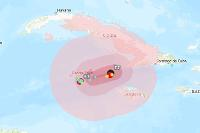

In [7]:
item

In [8]:
for lyr in item.layers:
    print(f"{lyr.properties.id}\t{lyr.properties.name}")

0	Events by Magnitude
1	Shake Intensity


In [9]:
quake = item.layers[0]

## Summarize C&D - sync, output service

In [10]:
from datetime import datetime
item = summarize_center_and_dispersion(analysis_layer=quake,
                                summarize_type=["CentralFeature","MeanCenter", "Ellipse"],
                                ellipse_size='2 standard deviations',
                                weight_field='mag',
                                group_field='magType',
                                output_name='test dffgvrdfbdffbg' + str(datetime.now().microsecond))

WARNING 000642: Problems reading 3 of 2392 total records.
WARNING 000848: Features with bad records (only includes first 30): OBJECTID = 1314, 1326, 2252.
WARNING 000941: Negative Weight values have been interpreted as zero for processing.
WARNING 000910: Too few features for 2 of 10 cases.
WARNING 000947: Cases with too few features (only includes first 30): MAGTYPE = MWb, Mh.


In [11]:
assert isinstance(item, Item)
assert len(item.layers) == 3

In [12]:
item.delete()

True

## Summarize C&D - sync, output FC

In [13]:
result = summarize_center_and_dispersion(analysis_layer=quake,
                                summarize_type=["CentralFeature","MeanCenter"],
                                weight_field='mag',
                                group_field='magType')

WARNING 000642: Problems reading 3 of 2392 total records.
WARNING 000848: Features with bad records (only includes first 30): OBJECTID = 1314, 1326, 2252.
WARNING 000941: Negative Weight values have been interpreted as zero for processing.


In [14]:
assert isinstance(result, dict)
assert isinstance(result['central_feature_result_layer'], FeatureCollection)
assert isinstance(result['mean_center_result_layer'], FeatureCollection)